# Making makemore

## What is makemore:
it's a character-level language model, basically you're predicting the next letter in a sequence of letters (i.e. the word).

In [17]:
words = open("names.txt").read().splitlines()
print(words[:10])
print(min(len(w) for w in words))
print(max(len(w) for w in words))

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia', 'harper', 'evelyn']
2
15


In [ ]:

dic = {}

for w in words:
    chs = ["."] + list(words) + ["."]
    for w1,w2 in zip(w,w[1:]) :
        dic[(w1,w2)] = dic.get((w1,w2),0) + 1
        print(w1,w2)



e m
m m
m a
o l
l i
i v
v i
i a
a v
v a
i s
s a
a b
b e
e l
l l
l a
s o
o p
p h
h i
i a
c h
h a
a r
r l
l o
o t
t t
t e
m i
i a
a m
m e
e l
l i
i a
h a
a r
r p
p e
e r
e v
v e
e l
l y
y n
a b
b i
i g
g a
a i
i l
e m
m i
i l
l y
e l
l i
i z
z a
a b
b e
e t
t h
m i
i l
l a
e l
l l
l a
a v
v e
e r
r y
s o
o f
f i
i a
c a
a m
m i
i l
l a
a r
r i
i a
s c
c a
a r
r l
l e
e t
t t
v i
i c
c t
t o
o r
r i
i a
m a
a d
d i
i s
s o
o n
l u
u n
n a
g r
r a
a c
c e
c h
h l
l o
o e
p e
e n
n e
e l
l o
o p
p e
l a
a y
y l
l a
r i
i l
l e
e y
z o
o e
e y
n o
o r
r a
l i
i l
l y
e l
l e
e a
a n
n o
o r
h a
a n
n n
n a
a h
l i
i l
l l
l i
i a
a n
a d
d d
d i
i s
s o
o n
a u
u b
b r
r e
e y
e l
l l
l i
i e
s t
t e
e l
l l
l a
n a
a t
t a
a l
l i
i e
z o
o e
l e
e a
a h
h a
a z
z e
e l
v i
i o
o l
l e
e t
a u
u r
r o
o r
r a
s a
a v
v a
a n
n n
n a
a h
a u
u d
d r
r e
e y
b r
r o
o o
o k
k l
l y
y n
b e
e l
l l
l a
c l
l a
a i
i r
r e
s k
k y
y l
l a
a r
l u
u c
c y
p a
a i
i s
s l
l e
e y
e v
v e
e r
r l


In [28]:
sorted(dic.items(), key = lambda kv: -kv[1])


[(('a', 'n'), 5438),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('a', 'l'), 2528),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('o', 'n'), 2411),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('a', 'y'), 2050),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('j', 'a'), 1473),
 (('n', 'e'), 1359),
 (('l', 'l'), 1345),
 (('i', 'l'), 1345),
 (('i', 's'), 1316),
 (('d', 'a'), 1303),
 (('s', 'h'), 1285),
 (('d', 'e'), 1283),
 (('e', 'e'), 1271),
 (('m', 'i'), 1256),
 (('s', 'a'), 1201),
 (('a', 's'), 1118),
 (('y', 'l'), 1104),
 (('e', 'y'), 1070),
 (('o', 'r'), 1059),
 (('a', 'd'), 1042),
 (('t', 'a'), 1027),
 (('v', 'i'), 911),
 (('k', 'e'), 

In [69]:
#we define a tensor with said letter:
import torch

m = torch.zeros((27,27), dtype=torch.int32)



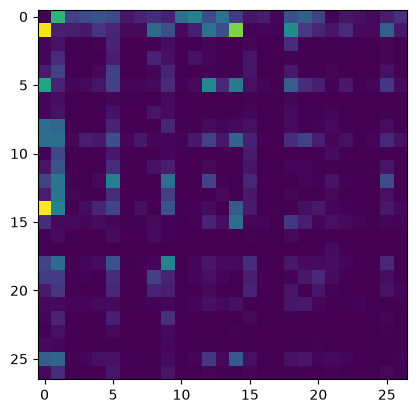

In [70]:
#we define a conversion list:
chars = sorted(list(set(''.join(words))))
equivalent = {ch: i+1 for ch, i in zip(chars, range(26))}
equivalent["."] =0 
nuivalent = {i:l for (l,i) in equivalent.items()}

for w in words:
    chs = ["."] + list(w) + ["."]
    for w1,w2 in zip(chs,chs[1:]) :
        m[equivalent[w1],equivalent[w2]] += 1

import matplotlib.pyplot as plt

plt.imshow(m)


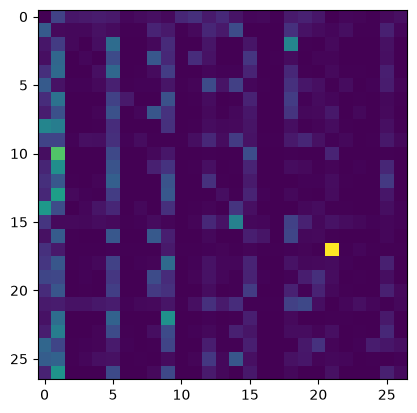

In [124]:
P = (m+1).float() # the +1 is added to ensure that no letter combination is neveroccuring.
P /= P.sum(1, keepdim = True) # to save memory

plt.imshow(P)


Here the `keepdim= True` is important for boeadcasting rights. remember we allign them from the right, then we check either same dim, one of them is 1 or one of them doesn't exist.

### Creating new names using a bigram LM:


In [121]:
#create new names using a bigram language model.
g = torch.Generator().manual_seed(2147483647)
out = []
for _ in range(10):
    xi = 0
    word = []
    while True:
        p = P[xi]


        xi = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        if nuivalent[xi] == ".":
            out.append(''.join(word))
            break
        else:
            word.append(nuivalent[xi])

print(out)


['cexze', 'momasurailezitynn', 'konimittain', 'llayn', 'ka', 'da', 'staiyaubrtthrigotai', 'moliellavo', 'ke', 'teda']


### The log-likelihood loss function:

In [132]:
loglikelyhood = 0.
n = 0
for w in words:
    
    chs = ["."] + list(w) + ["."]
    for w1,w2 in zip(chs,chs[1:]) :
        prob = -torch.log(P[equivalent[w1],equivalent[w2]])
        loglikelyhood += prob
        n += 1
loglikelyhood /= n #an average , which usually what is used as a loss function
print(f'{loglikelyhood:.4f}')


2.4544


In [127]:
#I can calculate the likelyhood of a specific word:

loglikelyhood = 0
w = "andrejq"
chs = ["."] + list(w) + ["."]
for w1,w2 in zip(chs,chs[1:]) :
    prob = -torch.log(P[equivalent[w1],equivalent[w2]])
    loglikelyhood += prob
print(loglikelyhood)

tensor(27.8672)


 Now we do the same but with an neural net. A layer of 27 neurones to be precise.

In [ ]:
import torch.nn.functional as F

xs = []
ys = []

for w in words:
    st = ['.'] + list(w) + ['.']
    for w1,w2 in zip(st,st[1:]):
        xs.append(equivalent[w1])
        ys.append(equivalent[w2])
    

#we turn then to tensors:
Xs = torch.tensor(xs)
Ys = torch.tensor(ys)
xenc = F.one_hot(Xs, num_classes = 27).float()


tensor([ 5, 13, 13,  ..., 26, 24,  0])


In [275]:
# now we create the neural net:

W = torch.randn((27,27),generator=g, requires_grad = True)



In [242]:


#now we need to create our counts:
logits =  xenc @ W
counts = logits.exp()

num = Xs.nelement()

Ps = counts / counts.sum(1, keepdim = True) # remember keep dim is important!
loss = -Ps[ torch.arange(num), ys].log().mean() # we pick probs for each duo and check our loss. it's picking Ps[xs,ys] basically and doing mean of log.
print(loss)
# now we want to do backprop:
W.grad = None


loss.backward()

with torch.no_grad():
    
    W += - 5 * W.grad


tensor(3.4318, grad_fn=<NegBackward0>)


In [306]:

# now we run our cycle :
for _ in range(20):

    #forward pass
    logits =  xenc @ W
    counts = logits.exp()

    num = Xs.nelement()

    Ps = counts / counts.sum(1, keepdim = True) # remember keep dim is important!
    loss = -Ps[ torch.arange(num), ys].log().mean() # we pick probs for each duo and check our loss. it's picking Ps[xs,ys] basically and doing mean of log.
    print(loss)
    # backward pass
    W.grad = None


    loss.backward()

    # updating params
    with torch.no_grad():
        
        W += - 70 * W.grad


tensor(2.4747, grad_fn=<NegBackward0>)
tensor(2.4595, grad_fn=<NegBackward0>)
tensor(2.4574, grad_fn=<NegBackward0>)
tensor(2.4569, grad_fn=<NegBackward0>)
tensor(2.4568, grad_fn=<NegBackward0>)
tensor(2.4565, grad_fn=<NegBackward0>)
tensor(2.4565, grad_fn=<NegBackward0>)
tensor(2.4563, grad_fn=<NegBackward0>)
tensor(2.4563, grad_fn=<NegBackward0>)
tensor(2.4562, grad_fn=<NegBackward0>)
tensor(2.4562, grad_fn=<NegBackward0>)
tensor(2.4562, grad_fn=<NegBackward0>)
tensor(2.4561, grad_fn=<NegBackward0>)
tensor(2.4561, grad_fn=<NegBackward0>)
tensor(2.4561, grad_fn=<NegBackward0>)
tensor(2.4561, grad_fn=<NegBackward0>)
tensor(2.4561, grad_fn=<NegBackward0>)
tensor(2.4561, grad_fn=<NegBackward0>)
tensor(2.4561, grad_fn=<NegBackward0>)
tensor(2.4561, grad_fn=<NegBackward0>)


In [312]:
# now we use this model :
wordlist = []
for _ in range(10):
    wrd = []
    srart = 0
    while True :
        
        srart = torch.multinomial(Ps[srart] , num_samples = 1, replacement = True, generator = g).item()
        if nuivalent[srart] == '.':
            break
        else :
            wrd.append(nuivalent[srart])
    wordlist.append(''.join(wrd))
print(wordlist)
        

['omx', 'dhziiononahror', 'dha', 'm', 'myar', 'h', 'mnifnalcaybba', 'temm', 'glefnayciiielana', 'dhya']


We can also add a smothing factor to our loss functions:

In [332]:


for _ in range(30):

    #forward pass
    logits =  xenc @ W
    counts = logits.exp()

    num = Xs.nelement()

    Ps = counts / counts.sum(1, keepdim = True) # remember keep dim is important!
    loss = -Ps[ torch.arange(num), ys].log().mean() + 0.05 * ((W**2).mean()) #mean squared being smaller means we have a sort of uniform model
    print(loss)
    # backward pass
    W.grad = None


    loss.backward()

    # updating params
    with torch.no_grad():
        
        W += - 20 * W.grad


tensor(2.5393, grad_fn=<AddBackward0>)
tensor(2.5393, grad_fn=<AddBackward0>)
tensor(2.5393, grad_fn=<AddBackward0>)
tensor(2.5393, grad_fn=<AddBackward0>)
tensor(2.5392, grad_fn=<AddBackward0>)
tensor(2.5392, grad_fn=<AddBackward0>)
tensor(2.5392, grad_fn=<AddBackward0>)
tensor(2.5392, grad_fn=<AddBackward0>)
tensor(2.5392, grad_fn=<AddBackward0>)
tensor(2.5391, grad_fn=<AddBackward0>)
tensor(2.5391, grad_fn=<AddBackward0>)
tensor(2.5391, grad_fn=<AddBackward0>)
tensor(2.5391, grad_fn=<AddBackward0>)
tensor(2.5391, grad_fn=<AddBackward0>)
tensor(2.5391, grad_fn=<AddBackward0>)
tensor(2.5390, grad_fn=<AddBackward0>)
tensor(2.5390, grad_fn=<AddBackward0>)
tensor(2.5390, grad_fn=<AddBackward0>)
tensor(2.5390, grad_fn=<AddBackward0>)
tensor(2.5390, grad_fn=<AddBackward0>)
tensor(2.5390, grad_fn=<AddBackward0>)
tensor(2.5390, grad_fn=<AddBackward0>)
tensor(2.5389, grad_fn=<AddBackward0>)
tensor(2.5389, grad_fn=<AddBackward0>)
tensor(2.5389, grad_fn=<AddBackward0>)
tensor(2.5389, grad_fn=<A

In [336]:
# we generate new words one more time:
wordlist = []
for _ in range(10):
    wrd = []
    srart = 0
    while True :
        
        srart = torch.multinomial(Ps[srart] , num_samples = 1, replacement = True, generator = g).item()
        if nuivalent[srart] == '.':
            break
        else :
            wrd.append(nuivalent[srart])
    wordlist.append(''.join(wrd))
print(wordlist)
        

['s', 'kzania', 'ekiyasnxybedldh', 'yd', 'kuea', 'mlsytroispredrteaymlfllsoraygiednaned', 'jdm', 'r', 'weiykec', 'spm']
